### <b>Phase 2: Data Preprocessing & Feature Engineering</b>

Importing libraries for preprocessing (scaling, encoding), train-test splitting, handling class imbalance (SMOTE), and statistical analysis.

In [1]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(r"E:\AIS bsc\predictive-maintenance\data\raw\AI4I_2020_Predictive_Maintenance_Dataset_(UCI).csv")
print(f"Dataset shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: (10000, 14)

Data types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


<b>Handling Missing Values and Outliers</b>

Checking for missing values, duplicates, and identifies outliers using the Interquartile Range (IQR) method. For maintenance data, outliers often signal equipment failure so these data points will be kept.

In [3]:
# Checking for missing values
print(f"Total missing values: {df.isnull().sum().sum()}")

# Checking for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Identifying outliers using IQR method for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
outliers_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outliers_summary[col] = outlier_count
    
print(f"\nOutliers by column:\n{pd.Series(outliers_summary)}")

Total missing values: 0
Duplicate rows: 0

Outliers by column:
UDI                          0
Air temperature [K]          0
Process temperature [K]      0
Rotational speed [rpm]     418
Torque [Nm]                 69
Tool wear [min]              0
Machine failure            339
TWF                         46
HDF                        115
PWF                         95
OSF                         98
RNF                         19
dtype: int64


<b>Encoding Categorical Features</b>

Converting categorical 'Type' (M, L, H) to numeric values. Drops ID columns (UDI, Product ID) since they don't provide predictive power.

In [4]:
# Encoding 'Type' column (M, L, H) to numeric values
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

# Show mapping
print("Type encoding:")
for i, class_ in enumerate(le.classes_):
    print(f"  {class_} → {i}")

# Dropping original Type column and Product ID (Since ID features are not predictive)
df = df.drop(columns=['Type', 'Product ID', 'UDI'])

print(f"\nDataFrame after encoding:\n{df.head()}")

Type encoding:
  H → 0
  L → 1
  M → 2

DataFrame after encoding:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  \
0         42.8                0                0    0    0    0    0    0   
1         46.3                3                0    0    0    0    0    0   
2         49.4                5                0    0    0    0    0    0   
3         39.5                7                0    0    0    0    0    0   
4         40.0                9                0    0    0    0    0    0   

   Type_encoded  
0 

<b>Separating Features and Targets</b>

The Fact weather a Machine Failure takes place or not and the different types of machine failure are the target features (y)

In [5]:
X = df.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])  # Drop target + failure modes
y = df['Machine failure']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:\n{X.columns.tolist()}")

Features shape: (10000, 6)
Target shape: (10000,)

Feature columns:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_encoded']


<b>Train-Test Split</b>

 Splitting data into 80% training and 20% testing. stratify=y ensures both sets have the same class ratio as the original data.

In [6]:
# Split data: 80% train, 20% test (stratified to maintain class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintains class distribution in both sets
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")

Training set size: 8000
Test set size: 2000

Training set class distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Test set class distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


<b>Feature Scaling</b>

Normalizing features to mean=0 and std=1. Fitting scaler only on training data to prevent data leakage.

In [7]:
# Initialize scaler
scaler = StandardScaler()

# Fitting scaler on training data only (to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converting back to DataFrame for easier interpretation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Scaled training data (first 5 rows):")
print(X_train_scaled.head())
print(f"\nMean of scaled features (should be ~0): \n{X_train_scaled.mean()}")
print(f"\nStd of scaled features (should be ~1): \n{X_train_scaled.std()}")

Scaled training data (first 5 rows):
      Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
4058             0.998914                 0.604282               -0.460607   
1221            -1.505194                -1.153260               -0.775574   
6895             0.498092                 1.077466               -1.007654   
9863            -0.553633                -0.139294               -0.709265   
8711            -1.455112                -1.018064                1.070019   

      Torque [Nm]  Tool wear [min]  Type_encoded  
4058     0.718305        -0.843997      1.341257  
1221     0.638456         0.382263      1.341257  
6895     0.558607         0.460870      1.341257  
9863     1.626586        -0.372359     -0.333221  
8711    -1.128202        -0.906882     -0.333221  

Mean of scaled features (should be ~0): 
Air temperature [K]        1.758593e-15
Process temperature [K]    1.053468e-14
Rotational speed [rpm]     3.010925e-16
Torque [Nm]               

<b>Handling Class Imbalance with SMOTE</b>

I used SMOTE (Synthetic Minority Oversampling) to create synthetic samples of the minority class. This balances the imbalanced dataset. Applied only to training data, not test data.

In [8]:
# Applying SMOTE to training data only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nBalanced training set distribution:\n{pd.Series(y_train_balanced).value_counts()}")
print(f"\nNew training set size: {X_train_balanced.shape[0]}")

# Converting to DataFrame
X_train_balanced = pd.DataFrame(X_train_balanced, columns=X.columns)

Original training set distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Balanced training set distribution:
Machine failure
0    7729
1    7729
Name: count, dtype: int64

New training set size: 15458


<b>Feature Correlation Analysis</b>

Shows which features are most correlated with machine failure. High correlation features are more predictive. Helps identify which features to keep/drop.

Feature correlation with Machine Failure:


Torque [Nm]                0.364217
Tool wear [min]            0.253522
Air temperature [K]        0.231346
Process temperature [K]    0.113345
Type_encoded              -0.041575
Rotational speed [rpm]    -0.066716
dtype: float64


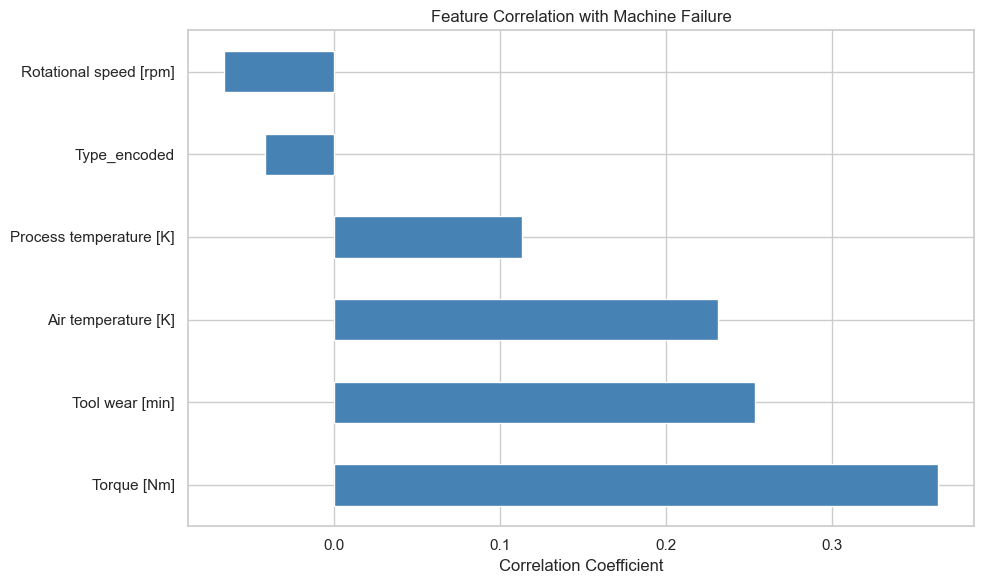

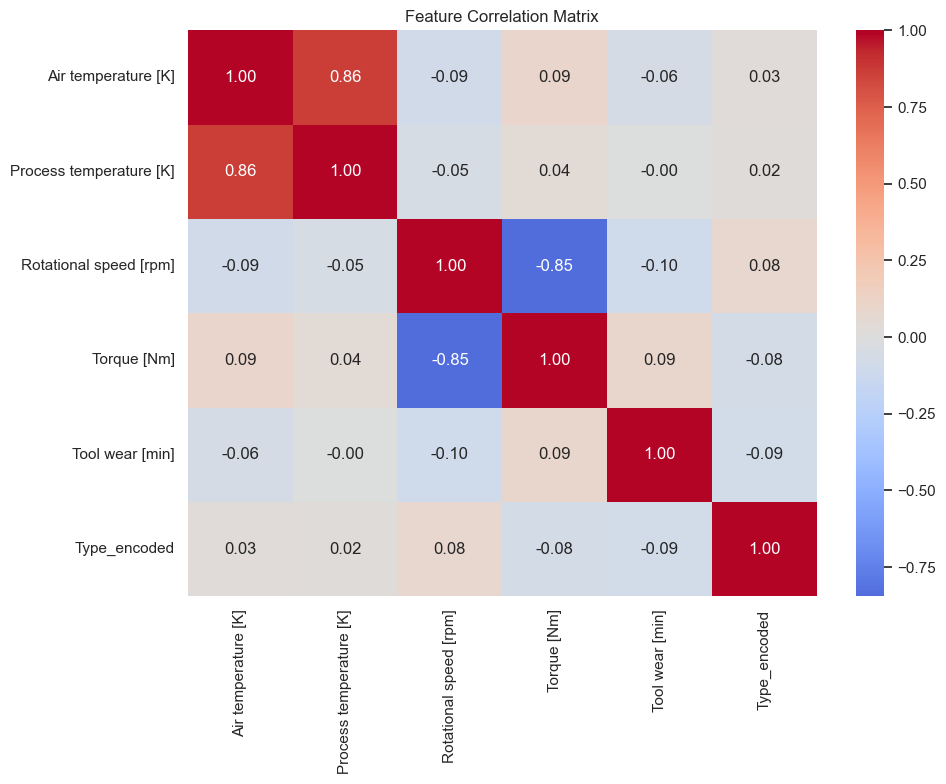

In [9]:
# Calculating correlation with target
correlation_with_target = X_train_balanced.corrwith(y_train_balanced).sort_values(ascending=False)

print("Feature correlation with Machine Failure:")
print(correlation_with_target)

# Visualize correlation
plt.figure(figsize=(10, 6))
correlation_with_target.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Machine Failure')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# Create correlation matrix heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = X_train_balanced.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

<b> Feature Importance via Variance Threshold </b>

Removes features with very low variance (they don't change much, so low predictive power).

In [10]:
from sklearn.feature_selection import VarianceThreshold

# Remove features with very low variance (near-constant features)
selector = VarianceThreshold(threshold=0.01)
X_train_high_var = selector.fit_transform(X_train_balanced)

# Get names of selected features
selected_features = X_train_balanced.columns[selector.get_support()].tolist()
print(f"Features after variance filtering: {selected_features}")

# Update all datasets
X_train_balanced = pd.DataFrame(X_train_high_var, columns=selected_features)
X_train_scaled = X_train_scaled[selected_features]
X_test_scaled = X_test_scaled[selected_features]

Features after variance filtering: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_encoded']


<b>Summary</b>

In [15]:
print("=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)
print(f"\nFinal Training Set: {X_train_balanced.shape}")
print(f"Final Test Set: {X_test_scaled.shape}")
print(f"\nFeatures used: {X_train_balanced.columns.tolist()}")
print(f"\nTraining set class distribution:\n{pd.Series(y_train_balanced).value_counts()}")

# Saving preprocessed data for next phase
preprocessed_data = {
    'X_train': X_train_balanced,
    'X_test': X_test_scaled,
    'y_train': y_train_balanced,
    'y_test': y_test,
    'scaler': scaler,
    'label_encoder': le
}

print("\n✓ Ready for Phase 3: Model Development!")

PREPROCESSING COMPLETE

Final Training Set: (15458, 6)
Final Test Set: (2000, 6)

Features used: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_encoded']

Training set class distribution:
Machine failure
0    7729
1    7729
Name: count, dtype: int64

✓ Ready for Phase 3: Model Development!


In [ ]:
# Saving the preprocessed data
X_train_balanced.to_csv('X_train_balanced.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)
y_train_balanced.to_csv('y_train_balanced.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# Saving scaler and encoder for later use
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']